### Model adjustment process

In [28]:
import os
from transformers import BeitForImageClassification, BeitFeatureExtractor, get_scheduler
from torch.optim import AdamW
from PIL import Image
import torch
import torch.nn as nn
from torchinfo import summary
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
from datetime import datetime
from pathlib import Path
import shutil
import json
import logging


In [11]:
# Load original model (still has 21841 classes)
raw_model_path = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/Raw_model/beit_base_patch16_model"
model = BeitForImageClassification.from_pretrained(raw_model_path)

# Assign correct label mappings
class_labels = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']
model.config.id2label = {i: label for i, label in enumerate(class_labels)}
model.config.label2id = {label: i for i, label in enumerate(class_labels)}
model.config.num_labels = len(class_labels)  #  Ensure num_labels is set

# Resize classifier layer (IMPORTANT STEP)
model.classifier = nn.Linear(model.classifier.in_features, model.config.num_labels)

# Set to eval mode
model.eval()

# Save adjusted model
adjusted_model_path = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model/adjusted_beit_model"
os.makedirs(adjusted_model_path, exist_ok=True)
model.save_pretrained(adjusted_model_path)

# Save feature extractor
feature_extractor = BeitFeatureExtractor.from_pretrained(raw_model_path)
feature_extractor.save_pretrained(adjusted_model_path)

print(" Model successfully adjusted to 7 classes and saved.")


 Model successfully adjusted to 7 classes and saved.


In [13]:
# Ensure adjusted model have seven class


adjusted_model_path = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model/adjusted_beit_model"
model = BeitForImageClassification.from_pretrained(adjusted_model_path)

print(" Number of output classes:", model.config.num_labels)
print(" id2label mapping:", model.config.id2label)


 Number of output classes: 7
 id2label mapping: {0: 'AKIEC', 1: 'BCC', 2: 'BKL', 3: 'DF', 4: 'MEL', 5: 'NV', 6: 'VASC'}


In [21]:
# === Load adjusted model ===
model_path = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model/adjusted_beit_model"
model = BeitForImageClassification.from_pretrained(model_path)
feature_extractor = BeitFeatureExtractor.from_pretrained(model_path)

model.eval()

# === Load test image ===
test_image_path = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/final_preprocess_images/nv/nv.071.jpg"  # Replace this path
image = Image.open(test_image_path).convert("RGB")

# === Preprocess image ===
inputs = feature_extractor(images=image, return_tensors="pt")

# === Inference ===
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_class_idx = logits.argmax(-1).item()

# === Print result ===
predicted_label = model.config.id2label[predicted_class_idx]
print(f"🧠 Predicted class: {predicted_label}")

🧠 Predicted class: MEL


In [ ]:
# Showing model summary

# Load your adjusted model
model_path = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model/adjusted_beit_model"
model = BeitForImageClassification.from_pretrained(model_path)

# Move model to device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# BEiT expects input shape: (batch_size, 3, 224, 224)
input_size = (1, 3, 224, 224)  # batch_size=1 for summary

# Print model summary
summary(model, input_size=input_size, device=str(device))

Layer (type:depth-idx)                                                 Output Shape              Param #
BeitForImageClassification                                             [1, 7]                    --
├─BeitModel: 1-1                                                       [1, 768]                  --
│    └─BeitEmbeddings: 2-1                                             [1, 197, 768]             768
│    │    └─BeitPatchEmbeddings: 3-1                                   [1, 196, 768]             590,592
│    │    └─Dropout: 3-2                                               [1, 197, 768]             --
│    └─BeitEncoder: 2-2                                                [1, 197, 768]             --
│    │    └─ModuleList: 3-3                                            --                        85,169,088
│    └─Identity: 2-3                                                   [1, 197, 768]             --
│    └─BeitPooler: 2-4                                                 [1, 768]  

In [ ]:
# Model unfreezing process


# === Paths ===
adjusted_model_path = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model/adjusted_beit_model"
unfrozen_model_path = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model/unfrozen_beit_model"
os.makedirs(unfrozen_model_path, exist_ok=True)

# === Load the model ===
model = BeitForImageClassification.from_pretrained(adjusted_model_path)

# === Unfreeze all layers ===
for name, param in model.named_parameters():
    param.requires_grad = True
print("All layers have been set to trainable (requires_grad=True).")

# === Print parameter stats ===
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# === Print number of output classes ===
print(f"Number of output classes: {model.config.num_labels}")
print(f"Class label mapping (id2label): {model.config.id2label}")

# === Save unfrozen model ===
model.save_pretrained(unfrozen_model_path)

# === Save the corresponding feature extractor ===
feature_extractor = BeitFeatureExtractor.from_pretrained(adjusted_model_path)
feature_extractor.save_pretrained(unfrozen_model_path)

print(f"Unfrozen model and feature extractor saved to:\n{unfrozen_model_path}")


✅ All layers have been set to trainable (requires_grad=True).
🔢 Total parameters:     85,767,367
🧠 Trainable parameters: 85,767,367
🧾 Number of output classes: 7
📌 Class label mapping (id2label): {0: 'AKIEC', 1: 'BCC', 2: 'BKL', 3: 'DF', 4: 'MEL', 5: 'NV', 6: 'VASC'}
✅ Unfrozen model and feature extractor saved to:
/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model/unfrozen_beit_model


### Fine tunning model

In [11]:
# === Paths ===
data_dir = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/final_Split_Images"
model_dir = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model/unfrozen_beit_model"
output_model_dir = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/fine tuned model/final_finetuned_beit"
os.makedirs(output_model_dir, exist_ok=True)

# === Device ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"💻 Using device: {device}")

# === Feature extractor & transform ===
feature_extractor = BeitFeatureExtractor.from_pretrained(model_dir)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=feature_extractor.image_mean, std=feature_extractor.image_std)
])

# === Load datasets ===
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

# === Load model ===
model = BeitForImageClassification.from_pretrained(model_dir)
model.to(device)

# === Loss & Optimizer ===
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=2e-5)

# === Evaluation helper ===
def evaluate(loader, model):
    model.eval()
    preds, labels = [], []
    total_loss = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(pixel_values=x)
            loss = criterion(outputs.logits, y)
            total_loss += loss.item()
            preds += outputs.logits.argmax(dim=-1).cpu().tolist()
            labels += y.cpu().tolist()
    acc = accuracy_score(labels, preds)
    return total_loss / len(loader), acc

# === Training ===
best_val_acc = 0
EPOCHS = 15

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"🔥 Epoch {epoch+1}/{EPOCHS}")
    for x, y in loop:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        outputs = model(pixel_values=x)
        loss = criterion(outputs.logits, y)
        loss.backward()
        optimizer.step()

        # === Accumulate metrics ===
        running_loss += loss.item()
        preds = outputs.logits.argmax(dim=-1)
        correct += (preds == y).sum().item()
        total += y.size(0)

        # === Live update progress bar ===
        loop.set_postfix({
            "Train Loss": f"{loss.item():.4f}",
            "Train Acc": f"{(correct / total) * 100:.2f}%"
        })

    # === Epoch summary ===
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    val_loss, val_acc = evaluate(val_loader, model)

    print(f"\n📊 Epoch {epoch+1} Summary:")
    print(f"   🟩 Train Loss: {train_loss:.4f} | 🟢 Train Acc: {train_acc*100:.2f}%")
    print(f"   🟨 Val Loss:   {val_loss:.4f} | 🔵 Val Acc:   {val_acc*100:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        model.save_pretrained(output_model_dir)
        feature_extractor.save_pretrained(output_model_dir)
        best_val_acc = val_acc
        print(f"✅ Best model saved at epoch {epoch+1} with Val Acc: {val_acc*100:.2f}%")

# === Final test evaluation ===
test_loss, test_acc = evaluate(test_loader, model)
print(f"\n🧪 Final Test Evaluation:")
print(f"   🟥 Test Loss: {test_loss:.4f} | 🧪 Test Accuracy: {test_acc*100:.2f}%")


💻 Using device: cpu


🔥 Epoch 1/15: 100%|██████████| 765/765 [48:46<00:00,  3.83s/it, Train Loss=0.8321, Train Acc=65.65%]  



📊 Epoch 1 Summary:
   🟩 Train Loss: 0.9329 | 🟢 Train Acc: 65.65%
   🟨 Val Loss:   0.5850 | 🔵 Val Acc:   77.99%
✅ Best model saved at epoch 1 with Val Acc: 77.99%


🔥 Epoch 2/15: 100%|██████████| 765/765 [49:48<00:00,  3.91s/it, Train Loss=0.1923, Train Acc=87.64%]  



📊 Epoch 2 Summary:
   🟩 Train Loss: 0.3662 | 🟢 Train Acc: 87.64%
   🟨 Val Loss:   0.4605 | 🔵 Val Acc:   84.40%
✅ Best model saved at epoch 2 with Val Acc: 84.40%


...


📊 Epoch 13 Summary:
   🟩 Train Loss: 0.0296 | 🟢 Train Acc: 99.05%
   🟨 Val Loss:   0.6078 | 🔵 Val Acc:   87.38%


🔥 Epoch 14/15: 100%|██████████| 765/765 [39:24<00:00,  3.09s/it, Train Loss=0.0284, Train Acc=98.97%]



📊 Epoch 14 Summary:
   🟩 Train Loss: 0.0335 | 🟢 Train Acc: 98.97%
   🟨 Val Loss:   0.6497 | 🔵 Val Acc:   87.03%


🔥 Epoch 15/15: 100%|██████████| 765/765 [36:53<00:00,  2.89s/it, Train Loss=0.0026, Train Acc=98.93%]



📊 Epoch 15 Summary:
   🟩 Train Loss: 0.0318 | 🟢 Train Acc: 98.93%
   🟨 Val Loss:   0.5835 | 🔵 Val Acc:   86.84%

🧪 Final Test Evaluation:
   🟥 Test Loss: 0.5393 | 🧪 Test Accuracy: 87.38%


In [15]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}


In [16]:
# Save history
history["train_loss"].append(train_loss)
history["train_acc"].append(train_acc)
history["val_loss"].append(val_loss)
history["val_acc"].append(val_acc)


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# === Plot Training & Validation Accuracy/Loss Curves ===
def plot_metrics(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(14, 6))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], 'b-o', label='Train Loss')
    plt.plot(epochs, history["val_loss"], 'r-o', label='Val Loss')
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], 'b-o', label='Train Acc')
    plt.plot(epochs, history["val_acc"], 'r-o', label='Val Acc')
    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


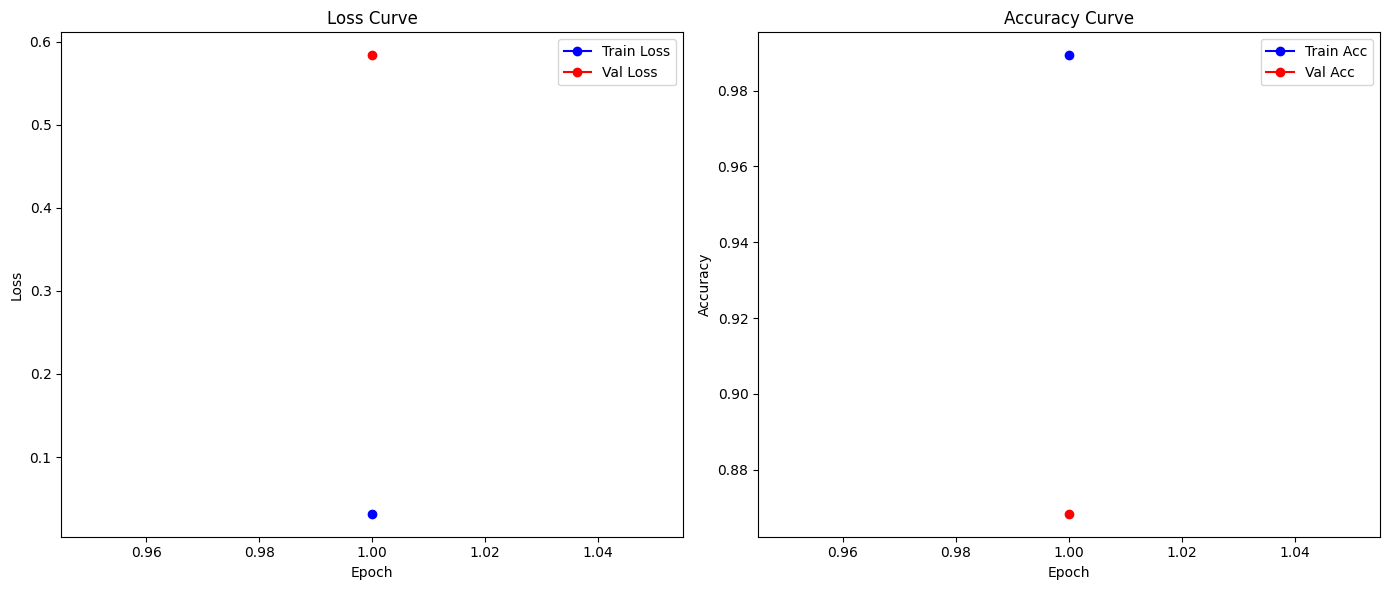

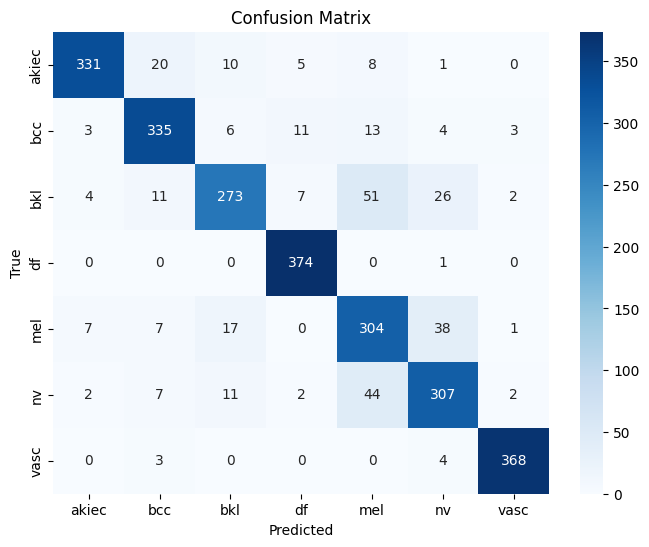

📋 Classification Report:

              precision    recall  f1-score   support

       akiec       0.95      0.88      0.92       375
         bcc       0.87      0.89      0.88       375
         bkl       0.86      0.73      0.79       374
          df       0.94      1.00      0.97       375
         mel       0.72      0.81      0.77       374
          nv       0.81      0.82      0.81       375
        vasc       0.98      0.98      0.98       375

    accuracy                           0.87      2623
   macro avg       0.88      0.87      0.87      2623
weighted avg       0.88      0.87      0.87      2623



In [18]:
# === Evaluate model on test set to get predictions ===
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        outputs = model(pixel_values=x)
        preds = outputs.logits.argmax(dim=-1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(y.numpy())

# === Plot Confusion Matrix ===
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

# === Classification Report ===
def print_classification_report(y_true, y_pred, class_names):
    print("📋 Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

# === Class Names ===
class_labels = train_dataset.classes  # or manually: ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']

# === Call Plots ===
plot_metrics(history)
plot_confusion_matrix(y_true, y_pred, class_labels)
print_classification_report(y_true, y_pred, class_labels)


In [1]:
import torch
import cv2
import numpy as np
from PIL import Image
from torchvision import transforms
from transformers import BeitForImageClassification, BeitFeatureExtractor

# === PATHS ===
image_path = "/Users/pasindumalinda/Downloads/Mapped_Images/akiec/ISIC_0024329.jpg"
model_path = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/fine tuned model/final_finetuned_beit"

# === DEVICE ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"💻 Using device: {device}")

# === LOAD MODEL & FEATURE EXTRACTOR ===
model = BeitForImageClassification.from_pretrained(model_path).to(device)
model.eval()
feature_extractor = BeitFeatureExtractor.from_pretrained(model_path)

# === IMPROVED INDUSTRIAL PREPROCESSING ===
def industrial_preprocess(image_path):
    # Load image in float32 RGB
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

    # --- Step 1: Denoising
    image = cv2.fastNlMeansDenoisingColored((image * 255).astype(np.uint8), None, 10, 10, 7, 21).astype(np.float32) / 255.0

    # --- Step 2: CLAHE per channel (RGB)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    channels = cv2.split((image * 255).astype(np.uint8))
    clahe_channels = [clahe.apply(c) for c in channels]
    image = cv2.merge(clahe_channels).astype(np.float32) / 255.0

    # --- Step 3: Unsharp masking for sharpening
    blurred = cv2.GaussianBlur(image, (5, 5), 1)
    image = cv2.addWeighted(image, 1.5, blurred, -0.5, 0)

    # --- Step 4: Resize with anti-aliasing
    image = cv2.resize(image, (224, 224), interpolation=cv2.INTER_AREA)

    # --- Step 5: Convert to PIL and normalize using BEiT standards
    pil_image = Image.fromarray((image * 255).astype(np.uint8))
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=feature_extractor.image_mean, std=feature_extractor.image_std)
    ])
    tensor = transform(pil_image).unsqueeze(0)
    return tensor

# === RUN INFERENCE ===
input_tensor = industrial_preprocess(image_path).to(device)

with torch.no_grad():
    outputs = model(pixel_values=input_tensor)
    logits = outputs.logits
    predicted_class = logits.argmax(dim=-1).item()
    predicted_label = model.config.id2label[predicted_class]

print(f"🧠 Predicted Skin Lesion Class: **{predicted_label}**")


💻 Using device: cpu


/Volumes/KODAK/folder_02/Skin_cancer_Detection/venv/lib/python3.11/site-packages/transformers/models/beit/feature_extraction_beit.py:30: FutureWarning: The class BeitFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use BeitImageProcessor instead.
  warnings.warn(


🧠 Predicted Skin Lesion Class: **BKL**


## Again try to fine tunning because prevoius model happend overfitted

In [13]:
#!/usr/bin/env python3
"""
Test script to verify all imports work correctly
"""

# Import Path at the top level so it's available globally
from pathlib import Path
import os

def test_imports():
    """Test all required imports"""
    try:
        import torch
        print("✅ torch imported successfully")
        
        import torch.nn as nn
        print("✅ torch.nn imported successfully")
        
        import torch.optim as optim
        print("✅ torch.optim imported successfully")
        
        from torch.utils.data import DataLoader
        print("✅ DataLoader imported successfully")
        
        import os
        print("✅ os imported successfully")
        
        import json
        print("✅ json imported successfully")
        
        import logging
        print("✅ logging imported successfully")
        
        from datetime import datetime
        print("✅ datetime imported successfully")
        
        import shutil
        print("✅ shutil imported successfully")
        
        from pathlib import Path
        print("✅ pathlib.Path imported successfully")
        
        import numpy as np
        print("✅ numpy imported successfully")
        
        from tqdm import tqdm
        print("✅ tqdm imported successfully")
        
        import sys
        print("✅ sys imported successfully")
        
        import warnings
        print("✅ warnings imported successfully")
        
        print("\n🎉 All imports successful!")
        
        # Test Path functionality
        test_path = Path("/tmp/test_path")
        print(f"✅ Path functionality works: {test_path}")
        
        # Test device detection
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"✅ Device detected: {device}")
        
        return True
        
    except ImportError as e:
        print(f"❌ Import error: {e}")
        return False
    except Exception as e:
        print(f"❌ Other error: {e}")
        return False

def check_paths():
    """Check if the specified paths exist"""
    MODEL_PATH = '/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model/unfrozen_beit_model'
    SAVE_PATH = '/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model/unfrozen_best_beit_model'
    
    print(f"\n📁 Checking paths...")
    
    if os.path.exists(MODEL_PATH):
        print(f"✅ Model path exists: {MODEL_PATH}")
    else:
        print(f"❌ Model path does not exist: {MODEL_PATH}")
        
    # Check if parent directory exists for save path
    save_parent = Path(SAVE_PATH).parent
    if save_parent.exists():
        print(f"✅ Save parent directory exists: {save_parent}")
    else:
        print(f"❌ Save parent directory does not exist: {save_parent}")
        
    # Try to create save directory
    try:
        Path(SAVE_PATH).mkdir(parents=True, exist_ok=True)
        print(f"✅ Save path created/verified: {SAVE_PATH}")
    except Exception as e:
        print(f"❌ Cannot create save path: {e}")

if __name__ == "__main__":
    print("🔍 Testing imports and paths for Gradual Unfreezing Trainer...")
    print("=" * 60)
    
    if test_imports():
        check_paths()
        print("\n✅ All tests passed! You can now run the main script.")
    else:
        print("\n❌ Some tests failed. Please install missing packages.")

🔍 Testing imports and paths for Gradual Unfreezing Trainer...
✅ torch imported successfully
✅ torch.nn imported successfully
✅ torch.optim imported successfully
✅ DataLoader imported successfully
✅ os imported successfully
✅ json imported successfully
✅ logging imported successfully
✅ datetime imported successfully
✅ shutil imported successfully
✅ pathlib.Path imported successfully
✅ numpy imported successfully
✅ tqdm imported successfully
✅ sys imported successfully
✅ warnings imported successfully

🎉 All imports successful!
✅ Path functionality works: /tmp/test_path
✅ Device detected: cpu

📁 Checking paths...
✅ Model path exists: /Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model/unfrozen_beit_model
✅ Save parent directory exists: /Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model
✅ Save path created/verified: /Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model/unfrozen_best_beit_model

✅ All tests passed! You can now run the ma

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import os
import json
import logging
from datetime import datetime
import shutil
from pathlib import Path
import numpy as np
from tqdm import tqdm
import sys
import warnings
warnings.filterwarnings('ignore')

# Try to import safetensors
try:
    from safetensors.torch import load_file as load_safetensors
    SAFETENSORS_AVAILABLE = True
except ImportError:
    SAFETENSORS_AVAILABLE = False
    print("Warning: safetensors not available. Install with: pip install safetensors")

class GradualUnfreezingTrainer:
    def __init__(self, model_path, save_base_path, num_classes=7):
        """
        Initialize the Gradual Unfreezing Trainer
        
        Args:
            model_path: Path to the unfrozen BEiT model
            save_base_path: Base path where processed models will be saved
            num_classes: Number of classes for skin cancer detection
        """
        # Validate inputs
        if not os.path.exists(model_path):
            raise FileNotFoundError(f"Model path does not exist: {model_path}")
        
        self.model_path = model_path
        self.save_base_path = Path(save_base_path)
        self.num_classes = num_classes
        
        # Create save directory if it doesn't exist
        self.save_base_path.mkdir(parents=True, exist_ok=True)
        
        # Create timestamp for this training session
        self.timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        self.session_dir = self.save_base_path / f"gradual_unfreezing_{self.timestamp}"
        self.session_dir.mkdir(parents=True, exist_ok=True)
        
        # Setup logging
        self.setup_logging()
        
        # Load model
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {self.device}")
        self.model = self.load_model()
        
        # Training configuration
        self.config = {
            'phase1_epochs': 5,      # Frozen backbone epochs
            'phase2_epochs': 3,      # Epochs per unfreezing stage
            'total_unfreeze_stages': 4,  # Number of gradual unfreezing stages
            'initial_lr': 1e-4,
            'classifier_lr': 1e-3,
            'weight_decay': 1e-4,
            'batch_size': 16,
            'warmup_epochs': 2
        }
        
        # Save configuration
        self.save_config()
        
        # Initialize training state
        self.current_phase = 1
        self.current_epoch = 0
        self.training_history = []
        
    def setup_logging(self):
        """Setup logging configuration"""
        log_file = self.session_dir / 'training.log'
        logging.basicConfig(
            level=logging.INFO,
            format='%(asctime)s - %(levelname)s - %(message)s',
            handlers=[
                logging.FileHandler(log_file),
                logging.StreamHandler()
            ]
        )
        self.logger = logging.getLogger(__name__)
        
    def find_model_files(self):
        """Find all potential model files in the directory"""
        model_files = []
        
        if os.path.isfile(self.model_path):
            # Direct file path
            return [self.model_path]
        
        if os.path.isdir(self.model_path):
            # Directory - search for model files (including safetensors)
            supported_extensions = ['.pth', '.bin', '.pt', '.pkl', '.safetensors']
            for root, dirs, files in os.walk(self.model_path):
                for file in files:
                    if any(file.endswith(ext) for ext in supported_extensions):
                        model_files.append(os.path.join(root, file))
        
        return model_files
    
    def load_safetensors_model(self, safetensors_path):
        """Load model from safetensors format"""
        if not SAFETENSORS_AVAILABLE:
            raise ImportError("safetensors library not available. Install with: pip install safetensors")
        
        self.logger.info(f"Loading safetensors model from: {safetensors_path}")
        
        # Load the state dict from safetensors
        state_dict = load_safetensors(safetensors_path)
        
        # Try to load config to understand the model architecture
        config_path = os.path.join(os.path.dirname(safetensors_path), 'config.json')
        if os.path.exists(config_path):
            with open(config_path, 'r') as f:
                config = json.load(f)
            self.logger.info(f"Loaded model config: {config.get('model_type', 'unknown')}")
            
            # Check if this is a transformers model
            if 'transformers' in str(type(state_dict)) or any('transformer' in key for key in state_dict.keys()):
                try:
                    from transformers import AutoModel
                    self.logger.info("Attempting to load with transformers AutoModel")
                    model = AutoModel.from_pretrained(os.path.dirname(safetensors_path))
                    return model
                except ImportError:
                    self.logger.warning("transformers not available, trying manual reconstruction")
                except Exception as e:
                    self.logger.warning(f"AutoModel loading failed: {e}, trying manual reconstruction")
        
        # If transformers loading fails, try to reconstruct based on state dict
        self.logger.info("Attempting manual model reconstruction from state dict")
        
        # Analyze the state dict structure
        self.logger.info("State dict keys analysis:")
        for key in list(state_dict.keys())[:10]:  # Show first 10 keys
            self.logger.info(f"  {key}: {state_dict[key].shape}")
        
        if len(state_dict) > 10:
            self.logger.info(f"  ... and {len(state_dict) - 10} more layers")
        
        # Try to create a simple model wrapper for the state dict
        class StateDict_Model(nn.Module):
            def __init__(self, state_dict):
                super().__init__()
                self.state_dict_loaded = state_dict
                
                # Try to identify key layers
                self.layers = nn.ModuleDict()
                
                # This is a placeholder - you might need to adjust based on your specific model
                self.logger_ref = logging.getLogger(__name__)
                self.logger_ref.info("Created StateDict_Model wrapper")
                
            def forward(self, x):
                # This is a placeholder forward method
                # You'll need to implement the actual forward pass based on your model
                raise NotImplementedError("Forward pass not implemented for StateDict_Model")
                
        # Create the wrapper model
        model = StateDict_Model(state_dict)
        
        # Load the state dict
        try:
            model.load_state_dict(state_dict, strict=False)
        except Exception as e:
            self.logger.warning(f"Could not load state dict directly: {e}")
            # Store state dict for manual access
            model.manual_state_dict = state_dict
        
        return model
    
    def load_model(self):
        """Load the unfrozen BEiT model with improved error handling"""
        self.logger.info(f"Loading model from: {self.model_path}")
        
        try:
            # First, find all potential model files
            model_files = self.find_model_files()
            
            if not model_files:
                # List directory contents for debugging
                self.logger.error("No model files found. Directory contents:")
                if os.path.isdir(self.model_path):
                    for item in os.listdir(self.model_path):
                        item_path = os.path.join(self.model_path, item)
                        if os.path.isfile(item_path):
                            size = os.path.getsize(item_path)
                            self.logger.error(f"  File: {item} ({size:,} bytes)")
                        else:
                            self.logger.error(f"  Directory: {item}")
                
                raise FileNotFoundError(f"No model files (.pth, .bin, .pt, .pkl, .safetensors) found in: {self.model_path}")
            
            # Try to load each model file
            self.logger.info(f"Found {len(model_files)} potential model files:")
            for i, file_path in enumerate(model_files, 1):
                size = os.path.getsize(file_path)
                self.logger.info(f"  {i}. {os.path.basename(file_path)} ({size:,} bytes, {size/(1024*1024):.2f} MB)")
            
            # Prioritize safetensors files
            safetensors_files = [f for f in model_files if f.endswith('.safetensors')]
            if safetensors_files:
                model_file = safetensors_files[0]
                self.logger.info(f"Using safetensors file: {model_file}")
                
                # Special handling for safetensors
                if SAFETENSORS_AVAILABLE:
                    # Option 1: Try to load with transformers (recommended)
                    try:
                        from transformers import AutoModel, AutoConfig
                        model_dir = os.path.dirname(model_file)
                        
                        self.logger.info("Attempting to load with transformers AutoModel")
                        model = AutoModel.from_pretrained(model_dir)
                        self.logger.info("Successfully loaded with transformers AutoModel")
                        
                        # Move to device
                        model.to(self.device)
                        
                        # Log model info
                        total_params = sum(p.numel() for p in model.parameters())
                        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
                        self.logger.info(f"Model has {total_params:,} total parameters")
                        self.logger.info(f"Currently {trainable_params:,} parameters are trainable")
                        
                        return model
                        
                    except ImportError:
                        self.logger.warning("transformers not available. Install with: pip install transformers")
                        self.logger.info("Falling back to manual safetensors loading")
                        
                    except Exception as e:
                        self.logger.warning(f"AutoModel loading failed: {e}")
                        self.logger.info("Falling back to manual safetensors loading")
                    
                    # Option 2: Manual safetensors loading
                    try:
                        model = self.load_safetensors_model(model_file)
                        model.to(self.device)
                        return model
                    except Exception as e:
                        self.logger.error(f"Manual safetensors loading failed: {e}")
                        
                else:
                    raise ImportError("safetensors library not available and .safetensors file found")
            
            # Fallback to traditional PyTorch files
            traditional_files = [f for f in model_files if not f.endswith('.safetensors')]
            if traditional_files:
                model_file = traditional_files[0]
                self.logger.info(f"Using traditional PyTorch file: {model_file}")
                
                # Load the model
                checkpoint = torch.load(model_file, map_location=self.device)
                
                # Handle different checkpoint formats
                if isinstance(checkpoint, dict):
                    if 'model' in checkpoint:
                        model = checkpoint['model']
                        self.logger.info("Loaded model from checkpoint['model']")
                    elif 'state_dict' in checkpoint:
                        self.logger.error("Found state_dict but no model architecture provided")
                        raise ValueError("State dict found but no model architecture provided")
                    elif 'model_state_dict' in checkpoint:
                        self.logger.error("Found model_state_dict but no model architecture provided")
                        raise ValueError("Model state dict found but no model architecture provided")
                    else:
                        # Assume the entire dict is the model
                        model = checkpoint
                        self.logger.info("Loaded entire checkpoint as model")
                else:
                    # Direct model object
                    model = checkpoint
                    self.logger.info("Loaded model object directly")
                
                # Move to device
                model.to(self.device)
                
                # Log model info
                total_params = sum(p.numel() for p in model.parameters())
                trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
                self.logger.info(f"Model has {total_params:,} total parameters")
                self.logger.info(f"Currently {trainable_params:,} parameters are trainable")
                
                return model
            
            raise ValueError("No suitable model files found")
            
        except Exception as e:
            self.logger.error(f"Error loading model: {str(e)}")
            self.logger.error(f"Error type: {type(e)}")
            import traceback
            self.logger.error(f"Traceback: {traceback.format_exc()}")
            raise
    
    def save_config(self):
        """Save training configuration"""
        config_file = self.session_dir / 'training_config.json'
        with open(config_file, 'w') as f:
            json.dump(self.config, f, indent=2)
        self.logger.info(f"Configuration saved to {config_file}")
    
    def freeze_backbone_train_classifier(self):
        """Phase 1: Freeze backbone, train only classifier"""
        self.logger.info("Phase 1: Freezing backbone, training only classifier")
        
        # Freeze all parameters first
        for param in self.model.parameters():
            param.requires_grad = False
        
        # Unfreeze classifier head - try different common names
        classifier_found = False
        
        # Try common classifier layer names
        for name, module in self.model.named_modules():
            if any(layer_name in name.lower() for layer_name in ['classifier', 'head', 'fc']):
                for param in module.parameters():
                    param.requires_grad = True
                self.logger.info(f"Unfroze classifier layer: {name}")
                classifier_found = True
        
        if not classifier_found:
            self.logger.warning("No obvious classifier layer found. Unfreezing last layer...")
            # Fallback: unfreeze the last layer
            layers = list(self.model.modules())
            if len(layers) > 1:
                for param in layers[-1].parameters():
                    param.requires_grad = True
                self.logger.info("Unfroze last layer as classifier")
        
        # Log trainable parameters
        self.log_trainable_parameters("Phase 1 - Classifier Only")
        
        # Save frozen model
        self.save_model_checkpoint("phase1_frozen_backbone")
        
    def gradual_unfreezing(self, stage):
        """Gradually unfreeze layers from top to bottom"""
        self.logger.info(f"Phase 2 - Stage {stage}: Gradual unfreezing")
        
        # Get all named parameters
        all_params = list(self.model.named_parameters())
        
        # Find layers that can be unfrozen (excluding classifier)
        backbone_params = [(name, param) for name, param in all_params 
                          if not any(x in name.lower() for x in ['classifier', 'head', 'fc'])]
        
        # Calculate how many layers to unfreeze
        total_layers = len(backbone_params)
        layers_per_stage = max(1, total_layers // self.config['total_unfreeze_stages'])
        
        # Unfreeze layers from top
        layers_to_unfreeze = layers_per_stage * stage
        
        self.logger.info(f"Total backbone layers: {total_layers}")
        self.logger.info(f"Layers per stage: {layers_per_stage}")
        self.logger.info(f"Layers to unfreeze in stage {stage}: {min(layers_to_unfreeze, total_layers)}")
        
        # Unfreeze from the end (top layers)
        for i in range(min(layers_to_unfreeze, total_layers)):
            name, param = backbone_params[-(i+1)]
            param.requires_grad = True
            self.logger.debug(f"Unfroze parameter: {name}")
        
        # Log trainable parameters
        self.log_trainable_parameters(f"Phase 2 - Stage {stage}")
        
        # Save model checkpoint
        self.save_model_checkpoint(f"phase2_stage{stage}_unfrozen")
        
    def log_trainable_parameters(self, phase_name):
        """Log information about trainable parameters"""
        total_params = sum(p.numel() for p in self.model.parameters())
        trainable_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        
        self.logger.info(f"{phase_name}:")
        self.logger.info(f"  Total parameters: {total_params:,}")
        self.logger.info(f"  Trainable parameters: {trainable_params:,}")
        self.logger.info(f"  Trainable percentage: {100 * trainable_params / total_params:.2f}%")
        
        # Count trainable layers
        trainable_layers = sum(1 for p in self.model.parameters() if p.requires_grad)
        self.logger.info(f"  Trainable layers: {trainable_layers}")
        
    def create_optimizer(self, phase):
        """Create optimizer based on training phase"""
        if phase == 1:
            # Phase 1: Only classifier parameters
            trainable_params = [p for p in self.model.parameters() if p.requires_grad]
            if not trainable_params:
                raise ValueError("No trainable parameters found for Phase 1")
            
            optimizer = optim.AdamW(
                trainable_params,
                lr=self.config['classifier_lr'],
                weight_decay=self.config['weight_decay']
            )
            self.logger.info(f"Phase 1 optimizer created with {len(trainable_params)} parameter groups")
        else:
            # Phase 2: Different learning rates for backbone and classifier
            backbone_params = []
            classifier_params = []
            
            for name, param in self.model.named_parameters():
                if param.requires_grad:
                    if any(layer_name in name.lower() for layer_name in ['classifier', 'head', 'fc']):
                        classifier_params.append(param)
                    else:
                        backbone_params.append(param)
            
            param_groups = []
            if backbone_params:
                param_groups.append({'params': backbone_params, 'lr': self.config['initial_lr']})
                self.logger.info(f"Backbone parameters: {len(backbone_params)}")
            
            if classifier_params:
                param_groups.append({'params': classifier_params, 'lr': self.config['classifier_lr']})
                self.logger.info(f"Classifier parameters: {len(classifier_params)}")
            
            if not param_groups:
                raise ValueError("No trainable parameters found for Phase 2")
            
            optimizer = optim.AdamW(param_groups, weight_decay=self.config['weight_decay'])
            self.logger.info(f"Phase 2 optimizer created with {len(param_groups)} parameter groups")
        
        return optimizer
    
    def save_model_checkpoint(self, checkpoint_name):
        """Save model checkpoint"""
        checkpoint_dir = self.session_dir / checkpoint_name
        checkpoint_dir.mkdir(exist_ok=True)
        
        # Save model state dict
        model_path = checkpoint_dir / 'pytorch_model.bin'
        torch.save(self.model.state_dict(), model_path)
        
        # Save full model
        full_model_path = checkpoint_dir / 'full_model.pth'
        torch.save(self.model, full_model_path)
        
        # Save training info
        info = {
            'phase': self.current_phase,
            'epoch': self.current_epoch,
            'timestamp': datetime.now().isoformat(),
            'device': str(self.device),
            'total_params': sum(p.numel() for p in self.model.parameters()),
            'trainable_params': sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        }
        
        info_path = checkpoint_dir / 'model_info.json'
        with open(info_path, 'w') as f:
            json.dump(info, f, indent=2)
        
        self.logger.info(f"Model checkpoint saved: {checkpoint_dir}")
        
    def train_epoch(self, dataloader, optimizer, criterion, phase_name):
        """Train for one epoch"""
        self.model.train()
        total_loss = 0
        correct = 0
        total = 0
        
        progress_bar = tqdm(dataloader, desc=f"{phase_name} - Epoch {self.current_epoch}")
        
        for batch_idx, (data, targets) in enumerate(progress_bar):
            data, targets = data.to(self.device), targets.to(self.device)
            
            optimizer.zero_grad()
            outputs = self.model(data)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            # Update progress bar
            progress_bar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{100.*correct/total:.2f}%'
            })
        
        avg_loss = total_loss / len(dataloader)
        accuracy = 100. * correct / total
        
        return avg_loss, accuracy
    
    def run_industrial_training(self, train_dataloader, val_dataloader=None):
        """Run the complete industrial training pipeline"""
        self.logger.info("Starting Industrial Gradual Unfreezing Training Pipeline")
        self.logger.info("=" * 60)
        
        criterion = nn.CrossEntropyLoss()
        
        # Phase 1: Frozen backbone training
        self.logger.info("PHASE 1: FROZEN BACKBONE TRAINING")
        self.logger.info("-" * 40)
        
        self.freeze_backbone_train_classifier()
        optimizer = self.create_optimizer(phase=1)
        
        for epoch in range(self.config['phase1_epochs']):
            self.current_epoch = epoch + 1
            
            train_loss, train_acc = self.train_epoch(
                train_dataloader, optimizer, criterion, "Phase 1"
            )
            
            self.logger.info(f"Phase 1 - Epoch {self.current_epoch}: "
                           f"Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%")
            
            # Save epoch info
            epoch_info = {
                'phase': 1,
                'epoch': self.current_epoch,
                'train_loss': train_loss,
                'train_accuracy': train_acc
            }
            self.training_history.append(epoch_info)
        
        # Phase 2: Gradual unfreezing
        self.logger.info("\nPHASE 2: GRADUAL UNFREEZING")
        self.logger.info("-" * 40)
        
        self.current_phase = 2
        
        for stage in range(1, self.config['total_unfreeze_stages'] + 1):
            self.logger.info(f"\nStage {stage} of {self.config['total_unfreeze_stages']}")
            
            # Apply gradual unfreezing
            self.gradual_unfreezing(stage)
            
            # Create new optimizer for this stage
            optimizer = self.create_optimizer(phase=2)
            
            # Train for specified epochs
            for epoch in range(self.config['phase2_epochs']):
                self.current_epoch = self.config['phase1_epochs'] + (stage - 1) * self.config['phase2_epochs'] + epoch + 1
                
                train_loss, train_acc = self.train_epoch(
                    train_dataloader, optimizer, criterion, f"Phase 2 - Stage {stage}"
                )
                
                self.logger.info(f"Stage {stage} - Epoch {self.current_epoch}: "
                               f"Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%")
                
                # Save epoch info
                epoch_info = {
                    'phase': 2,
                    'stage': stage,
                    'epoch': self.current_epoch,
                    'train_loss': train_loss,
                    'train_accuracy': train_acc
                }
                self.training_history.append(epoch_info)
        
        # Save final model and training history
        self.save_final_results()
        
        self.logger.info("\nINDUSTRIAL TRAINING PIPELINE COMPLETED!")
        self.logger.info("=" * 60)
        
    def save_final_results(self):
        """Save final training results"""
        # Save final model
        self.save_model_checkpoint("final_model")
        
        # Save training history
        history_file = self.session_dir / 'training_history.json'
        with open(history_file, 'w') as f:
            json.dump(self.training_history, f, indent=2)
        
        # Create summary report
        self.create_summary_report()
        
        self.logger.info(f"Final results saved in: {self.session_dir}")
        
    def create_summary_report(self):
        """Create a summary report of the training process"""
        report_file = self.session_dir / 'training_summary.txt'
        
        with open(report_file, 'w') as f:
            f.write("INDUSTRIAL GRADUAL UNFREEZING TRAINING SUMMARY\n")
            f.write("=" * 50 + "\n\n")
            
            f.write(f"Model Path: {self.model_path}\n")
            f.write(f"Save Path: {self.session_dir}\n")
            f.write(f"Training Date: {self.timestamp}\n")
            f.write(f"Device: {self.device}\n\n")
            
            f.write("TRAINING CONFIGURATION:\n")
            f.write("-" * 25 + "\n")
            for key, value in self.config.items():
                f.write(f"{key}: {value}\n")
            f.write("\n")
            
            f.write("TRAINING PHASES:\n")
            f.write("-" * 15 + "\n")
            f.write(f"Phase 1 (Frozen Backbone): {self.config['phase1_epochs']} epochs\n")
            f.write(f"Phase 2 (Gradual Unfreezing): {self.config['total_unfreeze_stages']} stages, "
                   f"{self.config['phase2_epochs']} epochs each\n")
            f.write(f"Total Training Epochs: {self.current_epoch}\n\n")
            
            if self.training_history:
                f.write("TRAINING PROGRESS:\n")
                f.write("-" * 17 + "\n")
                for entry in self.training_history:
                    if entry['phase'] == 1:
                        f.write(f"Phase 1 - Epoch {entry['epoch']}: "
                               f"Loss: {entry['train_loss']:.4f}, Acc: {entry['train_accuracy']:.2f}%\n")
                    else:
                        f.write(f"Phase 2 Stage {entry['stage']} - Epoch {entry['epoch']}: "
                               f"Loss: {entry['train_loss']:.4f}, Acc: {entry['train_accuracy']:.2f}%\n")
        
        self.logger.info(f"Training summary saved: {report_file}")


def main():
    """Main function to run the industrial training pipeline"""
    
    # Configuration
    MODEL_PATH = '/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model/unfrozen_beit_model'
    SAVE_PATH = '/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model'
    
    try:
        # Check required libraries
        print("Checking required libraries...")
        
        # Check safetensors
        try:
            from safetensors.torch import load_file
            print("✅ safetensors available")
        except ImportError:
            print("❌ safetensors not available. Install with: pip install safetensors")
            return
        
        # Check transformers (recommended for BEiT models)
        try:
            from transformers import AutoModel
            print("✅ transformers available")
        except ImportError:
            print("⚠️  transformers not available. Install with: pip install transformers")
            print("   (Recommended for BEiT models)")
        
        # Initialize trainer
        trainer = GradualUnfreezingTrainer(
            model_path=MODEL_PATH,
            save_base_path=SAVE_PATH,
            num_classes=7  # Adjust based on your skin cancer classes
        )
        
        # Success message
        print("✅ Trainer initialized successfully!")
        print(f"📁 Session directory: {trainer.session_dir}")
        print("\nTo start training, call:")
        print("trainer.run_industrial_training(train_dataloader, val_dataloader)")
        
        # Example of how to use (uncomment when you have dataloaders):
        # trainer.run_industrial_training(train_dataloader, val_dataloader)
        
    except Exception as e:
        print(f"❌ Error initializing trainer: {e}")
        print("\nTroubleshooting steps:")
        print("1. Install required libraries:")
        print("   pip install safetensors transformers")
        print("2. Verify model files exist in the directory")
        print("3. Check the error log for detailed information")


if __name__ == "__main__":
    main()

2025-07-15 09:58:32,338 - INFO - Loading model from: /Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model/unfrozen_beit_model
2025-07-15 09:58:32,340 - INFO - Found 2 potential model files:
2025-07-15 09:58:32,340 - INFO -   1. model.safetensors (343,095,708 bytes, 327.20 MB)
2025-07-15 09:58:32,341 - INFO -   2. ._model.safetensors (4,096 bytes, 0.00 MB)
2025-07-15 09:58:32,341 - INFO - Using safetensors file: /Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model/unfrozen_beit_model/model.safetensors
2025-07-15 09:58:32,341 - INFO - Attempting to load with transformers AutoModel


Checking required libraries...
✅ safetensors available
✅ transformers available
Using device: cpu


2025-07-15 09:58:34,584 - INFO - Successfully loaded with transformers AutoModel
2025-07-15 09:58:34,587 - INFO - Model has 85,761,984 total parameters
2025-07-15 09:58:34,587 - INFO - Currently 85,761,984 parameters are trainable
2025-07-15 09:58:34,590 - INFO - Configuration saved to /Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model/gradual_unfreezing_20250715_095832/training_config.json


✅ Trainer initialized successfully!
📁 Session directory: /Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model/gradual_unfreezing_20250715_095832

To start training, call:
trainer.run_industrial_training(train_dataloader, val_dataloader)


In [29]:


# === PATHS ===
data_dir = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/final_Split_Images"
frozen_model_path = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model/unfrozen_beit_model"
output_model_dir = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/fine tuned model/frozen_to_unfrozen_finetuned"
os.makedirs(output_model_dir, exist_ok=True)

# === DEVICE ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# === Load Processor & Define Transforms ===
processor = BeitImageProcessor.from_pretrained(frozen_model_path)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

# === Load Dataset ===
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

# === Class Weights ===
labels = train_dataset.targets
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# === Load Model and Freeze Base ===
model = BeitForImageClassification.from_pretrained(frozen_model_path).to(device)
for name, param in model.named_parameters():
    param.requires_grad = False
for name, param in model.classifier.named_parameters():
    param.requires_grad = True

# === Loss & Optimizer & Scheduler ===
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
lr_scheduler = get_scheduler("cosine", optimizer=optimizer, num_warmup_steps=0, num_training_steps=30 * len(train_loader))

# === Evaluate ===
def evaluate(loader):
    model.eval()
    all_preds, all_labels, total_loss = [], [], 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(pixel_values=x)
            loss = criterion(outputs.logits, y)
            total_loss += loss.item()
            all_preds += outputs.logits.argmax(dim=-1).cpu().tolist()
            all_labels += y.cpu().tolist()
    acc = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader), acc

# === Train Loop ===
EPOCHS = 30
best_val_acc = 0
early_stop_counter = 0
patience = 3
unfreeze_epoch = 5

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0
    loop = tqdm(train_loader, desc=f"🔥 Epoch {epoch+1}/{EPOCHS}")

    for x, y in loop:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(pixel_values=x)
        loss = criterion(outputs.logits, y)
        loss.backward()
        optimizer.step()
        lr_scheduler.step()

        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=-1)
        correct += (preds == y).sum().item()
        total += y.size(0)

        loop.set_postfix(loss=loss.item(), acc=f"{(correct/total)*100:.2f}%")

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total
    val_loss, val_acc = evaluate(val_loader)

    print(f"\n📊 Epoch {epoch+1} Summary:")
    print(f"   🟩 Train Loss: {train_loss:.4f} | 🟢 Train Acc: {train_acc*100:.2f}%")
    print(f"   🟨 Val Loss:   {val_loss:.4f} | 🔵 Val Acc:   {val_acc*100:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        model.save_pretrained(output_model_dir)
        processor.save_pretrained(output_model_dir)
        best_val_acc = val_acc
        early_stop_counter = 0
        print(f"✅ Model saved at epoch {epoch+1}")
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"🛑 Early stopping at epoch {epoch+1}")
            break

    # === Gradual Unfreezing ===
    if epoch + 1 == unfreeze_epoch:
        print("🔓 Unfreezing encoder layer 10 & 11...")
        for name, param in model.named_parameters():
            if "encoder.layer.10" in name or "encoder.layer.11" in name:
                param.requires_grad = True
        optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
        lr_scheduler = get_scheduler(
            name="cosine",
            optimizer=optimizer,
            num_warmup_steps=0,
            num_training_steps=(EPOCHS - epoch - 1) * len(train_loader)
        )

# === Final Test Eval ===
test_loss, test_acc = evaluate(test_loader)
print(f"\n🧪 Final Test Accuracy: {test_acc*100:.2f}% | 🟥 Test Loss: {test_loss:.4f}")


Using device: cpu


🔥 Epoch 1/30: 100%|██████████| 765/765 [09:55<00:00,  1.28it/s, acc=19.74%, loss=1.83]



📊 Epoch 1 Summary:
   🟩 Train Loss: 1.9373 | 🟢 Train Acc: 19.74%
   🟨 Val Loss:   1.8518 | 🔵 Val Acc:   25.36%
✅ Model saved at epoch 1


🔥 Epoch 2/30: 100%|██████████| 765/765 [09:49<00:00,  1.30it/s, acc=31.49%, loss=1.76]



📊 Epoch 2 Summary:
   🟩 Train Loss: 1.7905 | 🟢 Train Acc: 31.49%
   🟨 Val Loss:   1.7346 | 🔵 Val Acc:   34.94%
✅ Model saved at epoch 2


...


📊 Epoch 26 Summary:
   🟩 Train Loss: 0.3312 | 🟢 Train Acc: 89.70%
   🟨 Val Loss:   0.4013 | 🔵 Val Acc:   85.77%


🔥 Epoch 27/30: 100%|██████████| 765/765 [13:11<00:00,  1.03s/it, acc=90.16%, loss=0.11]  



📊 Epoch 27 Summary:
   🟩 Train Loss: 0.3317 | 🟢 Train Acc: 90.16%
   🟨 Val Loss:   0.4031 | 🔵 Val Acc:   85.62%


🔥 Epoch 28/30: 100%|██████████| 765/765 [13:21<00:00,  1.05s/it, acc=90.23%, loss=0.386] 



📊 Epoch 28 Summary:
   🟩 Train Loss: 0.3274 | 🟢 Train Acc: 90.23%
   🟨 Val Loss:   0.4008 | 🔵 Val Acc:   86.04%
🛑 Early stopping at epoch 28

🧪 Final Test Accuracy: 85.78% | 🟥 Test Loss: 0.4031



📋 Classification Report:
              precision    recall  f1-score   support

       akiec     0.8557    0.9333    0.8929       375
         bcc     0.8505    0.8347    0.8425       375
         bkl     0.7920    0.6925    0.7389       374
          df     0.9639    0.9973    0.9803       375
         mel     0.7461    0.7701    0.7579       374
          nv     0.8348    0.7813    0.8072       375
        vasc     0.9416    0.9893    0.9649       375

    accuracy                         0.8570      2623
   macro avg     0.8550    0.8569    0.8549      2623
weighted avg     0.8550    0.8570    0.8550      2623



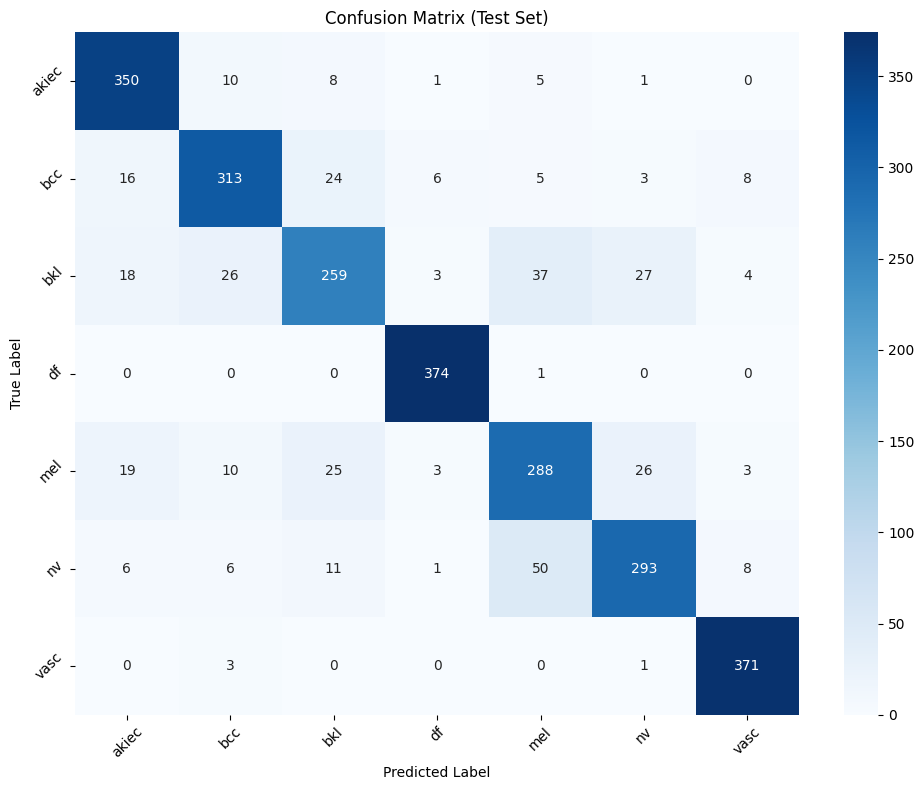

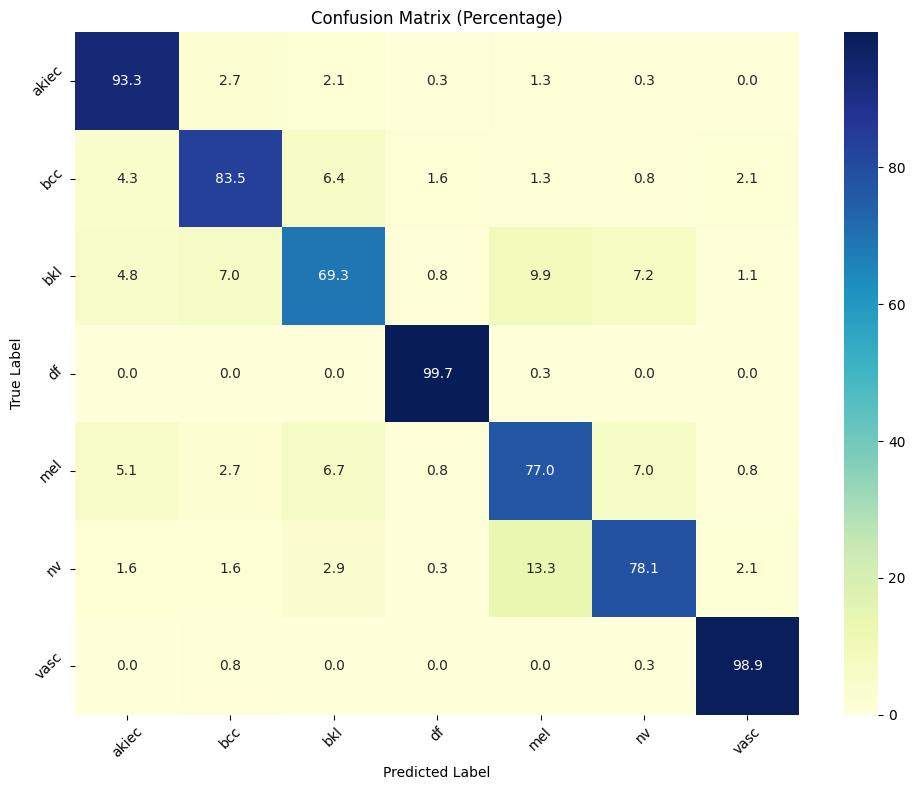

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# === Get True & Predicted Labels on Test Set ===
def get_preds_and_labels(loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(pixel_values=x)
            preds = outputs.logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(y.cpu().tolist())
    return all_preds, all_labels

preds, labels = get_preds_and_labels(test_loader)

# === Class Labels ===
class_names = test_dataset.classes  # ImageFolder infers from subfolder names

# === Classification Report ===
print("\n📋 Classification Report:")
print(classification_report(labels, preds, target_names=class_names, digits=4))

# === Confusion Matrix ===
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# === Optional: Confusion Matrix as % Accuracy per class ===
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt=".1f", cmap="YlGnBu", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Percentage)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()


In [182]:
import torch
import cv2
import numpy as np
from PIL import Image
from torchvision import transforms
from transformers import BeitForImageClassification, BeitFeatureExtractor

# === PATHS ===
image_path = "/Users/pasindumalinda/Downloads/Mapped_Images/vasc/ISIC_0024375.jpg"
model_path = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/fine tuned model/frozen_to_unfrozen_finetuned"

# === DEVICE ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"💻 Using device: {device}")

# === LOAD MODEL & FEATURE EXTRACTOR ===
model = BeitForImageClassification.from_pretrained(model_path).to(device)
model.eval()
feature_extractor = BeitFeatureExtractor.from_pretrained(model_path)

# === IMPROVED INDUSTRIAL PREPROCESSING ===
def industrial_preprocess(image_path):
    # Load image in float32 RGB
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

    # --- Step 1: Denoising
    image = cv2.fastNlMeansDenoisingColored((image * 255).astype(np.uint8), None, 10, 10, 7, 21).astype(np.float32) / 255.0

    # --- Step 2: CLAHE per channel (RGB)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    channels = cv2.split((image * 255).astype(np.uint8))
    clahe_channels = [clahe.apply(c) for c in channels]
    image = cv2.merge(clahe_channels).astype(np.float32) / 255.0

    # --- Step 3: Unsharp masking for sharpening
    blurred = cv2.GaussianBlur(image, (5, 5), 1)
    image = cv2.addWeighted(image, 1.5, blurred, -0.5, 0)

    # --- Step 4: Resize with anti-aliasing
    image = cv2.resize(image, (224, 224), interpolation=cv2.INTER_AREA)

    # --- Step 5: Convert to PIL and normalize using BEiT standards
    pil_image = Image.fromarray((image * 255).astype(np.uint8))
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=feature_extractor.image_mean, std=feature_extractor.image_std)
    ])
    tensor = transform(pil_image).unsqueeze(0)
    return tensor

# === RUN INFERENCE ===
input_tensor = industrial_preprocess(image_path).to(device)

with torch.no_grad():
    outputs = model(pixel_values=input_tensor)
    logits = outputs.logits
    predicted_class = logits.argmax(dim=-1).item()
    predicted_label = model.config.id2label[predicted_class]

print(f"🧠 Predicted Skin Lesion Class: **{predicted_label}**")


💻 Using device: cpu
🧠 Predicted Skin Lesion Class: **BCC**


In [189]:
import torch
import cv2
import numpy as np
from PIL import Image
from torchvision import transforms
from transformers import BeitForImageClassification, BeitFeatureExtractor
import os

# === PATHS ===
image_path = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/final_Split_Images/test/bkl/bkl.087.jpg"
model_path = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/fine tuned model/frozen_to_unfrozen_finetuned"

# === DEVICE ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"💻 Using device: {device}")

# === LOAD MODEL & PROCESSOR ===
model = BeitForImageClassification.from_pretrained(model_path).to(device)
model.eval()

# Load feature extractor (deprecated) or new processor
try:
    from transformers import BeitImageProcessor
    processor = BeitImageProcessor.from_pretrained(model_path)
except ImportError:
    processor = BeitFeatureExtractor.from_pretrained(model_path)

# === INDUSTRIAL INFERENCE PREPROCESSING ===
def industrial_preprocess(image_path):
    # Load and ensure RGB format
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

    # --- Step 1: Denoising
    image = cv2.fastNlMeansDenoisingColored((image * 255).astype(np.uint8), None, 10, 10, 7, 21).astype(np.float32) / 255.0

    # --- Step 2: CLAHE per channel
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    channels = cv2.split((image * 255).astype(np.uint8))
    clahe_channels = [clahe.apply(c) for c in channels]
    image = cv2.merge(clahe_channels).astype(np.float32) / 255.0

    # --- Step 3: Sharpening via Unsharp Masking
    blurred = cv2.GaussianBlur(image, (3, 3), 1)
    image = cv2.addWeighted(image, 1.5, blurred, -0.5, 0)

    # --- Step 4: Resize to BEiT size (224x224) with anti-aliasing
    image = cv2.resize(image, (224, 224), interpolation=cv2.INTER_AREA)

    # --- Step 5: Convert to tensor & normalize
    pil_image = Image.fromarray((image * 255).astype(np.uint8))
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
    ])
    tensor = transform(pil_image).unsqueeze(0)
    return tensor

# === RUN ROBUST INFERENCE ===
input_tensor = industrial_preprocess(image_path).to(device)

with torch.no_grad():
    outputs = model(pixel_values=input_tensor)
    predicted_class = outputs.logits.argmax(dim=-1).item()
    predicted_label = model.config.id2label[predicted_class]

print(f"🧠 Predicted Skin Lesion Class: **{predicted_label}**")


💻 Using device: cpu
🧠 Predicted Skin Lesion Class: **BCC**
